# Simulator-in-the-Loop Bayesian Inference with Tesseract

In this tutorial, you will learn how to use a Tesseract as the forward model inside a [NumPyro](https://num.pyro.ai/) probabilistic programming workflow. We will:

1. **Wrap a simulator as a Tesseract** — the Lorenz 96 chaotic dynamical system
2. **Embed it in a NumPyro model** — using [tesseract-jax](https://github.com/pasteurlabs/tesseract-jax) to make the Tesseract a native JAX primitive
3. **Run Bayesian inference** — recover posterior distributions over simulator parameters from noisy observations using NUTS (gradient-based MCMC)
4. **Compare gradient strategies** — analytical (JAX autodiff) vs. finite differences vs. gradient-free sampling

## Why this matters

Probabilistic programming languages (PPLs) need a forward model they can differentiate through. Connecting a simulator to a PPL usually means writing a custom wrapper that exposes the simulator and its gradients to the sampler by hand. With Tesseract, you wrap the simulator once and it becomes a JAX-differentiable primitive that plugs directly into NumPyro (or any JAX-based PPL). The same Tesseract is also deployable, composable, and reusable in optimization, ML pipelines, and other contexts.

## The problem

We have a chaotic dynamical system (Lorenz 96) with an unknown forcing parameter $F$. We observe a noisy, short trajectory and want to recover the posterior distribution $p(F \mid \text{observations})$. This is a classic inverse problem that arises in weather forecasting, climate science, and many other fields.

Because Lorenz 96 is chaotic, the likelihood landscape is rugged for long integration windows. We work with short observation windows where the model response to $F$ is smooth — exactly the regime where gradient-based sampling shines.

In [1]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


## Step 1: Build and serve the Tesseract

We use the Lorenz 96 system — a standard benchmark in data assimilation and UQ. This is the *same* JAX-based Tesseract used in the [4D-Var data assimilation demo](data-assimilation.ipynb), living in its `lorenz_tesseract` folder: analytical gradients via `jax.vjp`, with a differentiable forcing parameter $F$. We wrap the simulator once and reuse it here. We also have a `lorenz_tesseract_finitediff` variant that uses pure NumPy and finite-difference gradients, simulating an opaque simulator where source code isn't available.

In [2]:
%%bash
# Render build status statically instead of an animated spinner,
# which streams as noise in captured notebook output.
export TERM=dumb
tesseract build ../data-assimilation/lorenz_tesseract/

 [i] Building image ...


 [i] Built image sha256:863814f6d3d4, ['lorenz:0.1.0', 'lorenz:latest']


["lorenz:0.1.0", "lorenz:latest"]


In [3]:
from tesseract_core import Tesseract

lorenz = Tesseract.from_image("lorenz")
lorenz.serve()

## Step 2: Generate synthetic observations

We generate ground-truth data by running the Lorenz 96 model with the true forcing $F = 18$, then add Gaussian noise to simulate noisy measurements. We use short observation windows (10 time steps apart) to keep the likelihood landscape well-behaved.

In [4]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tesseract_jax import apply_tesseract

# Load an initial condition from the two-scale Lorenz 96 system
data = np.load("lorenz96_two_scale_F_18_sample_0_small.npz")
X_states = data["X_states"]
true_trajectory = X_states[500:]  # skip transients
X0 = true_trajectory[0]
N_DIM = X0.shape[0]  # 8 slow variables

# Observation setup
OBS_GAP = 10  # time steps between observations
N_OBS = 3  # number of observations
STD_OBS = 0.5  # observation noise standard deviation
TRUE_F = 18.0  # true forcing parameter
N_STEPS = OBS_GAP * N_OBS

x0_jax = jnp.array(X0, dtype=jnp.float32)

# Generate ground-truth trajectory with the true F
true_result = apply_tesseract(
    lorenz,
    {"state": x0_jax, "F": jnp.float32(TRUE_F), "dt": 0.005, "n_steps": N_STEPS},
)
true_traj = true_result["result"]

# Extract states at observation times and add noise
obs_indices = jnp.arange(OBS_GAP - 1, N_STEPS, OBS_GAP)
true_obs = true_traj[obs_indices]

key = jax.random.PRNGKey(42)
observations = true_obs + STD_OBS * jax.random.normal(key, true_obs.shape)

print(f"System dimension: {N_DIM}")
print(f"Number of observations: {N_OBS}")
print(f"Observations shape: {observations.shape}")

System dimension: 8
Number of observations: 3
Observations shape: (3, 8)


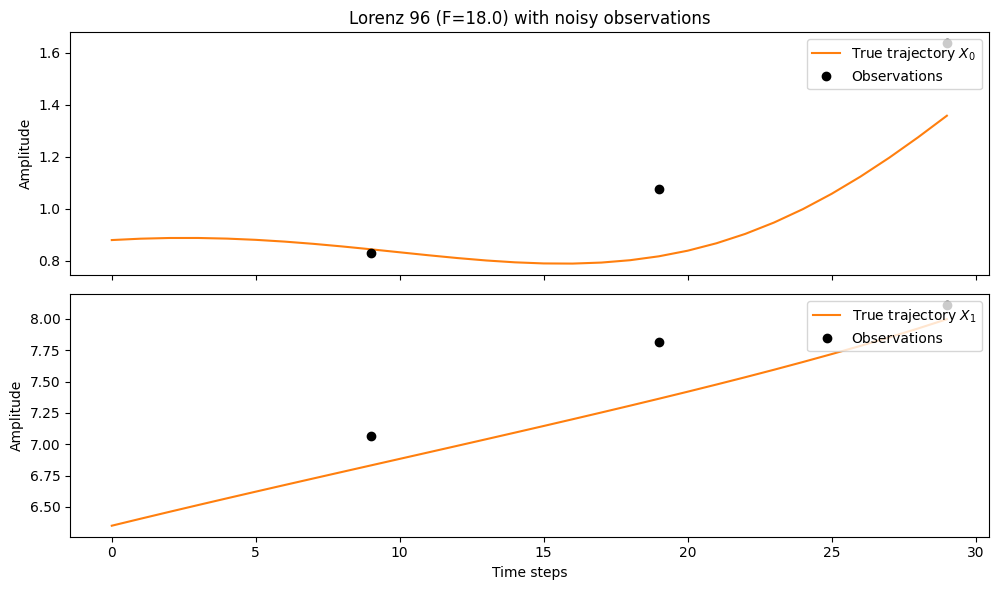

In [5]:
# Visualize the ground truth trajectory and observations
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for pos, ax in enumerate(axes):
    ax.plot(np.array(true_traj[:, pos]), label=f"True trajectory $X_{pos}$", color="C1")
    ax.plot(
        np.array(obs_indices),
        np.array(observations[:, pos]),
        "ko",
        ms=6,
        label="Observations",
    )
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time steps")
axes[0].set_title(f"Lorenz 96 (F={TRUE_F}) with noisy observations")
plt.tight_layout()
plt.show()

## Step 3: Define the NumPyro model

This is the key integration. We use `apply_tesseract` from [tesseract-jax](https://github.com/pasteurlabs/tesseract-jax) to call the Tesseract as a JAX primitive inside a NumPyro probabilistic model.

Because `apply_tesseract` registers the Tesseract as a proper JAX operation (with `abstract_eval` and `vector_jacobian_product`), NumPyro's NUTS sampler can differentiate through it automatically. No custom `jax.pure_callback` or `jax.custom_vjp` wiring needed.

**The model:**
- **Prior:** $F \sim \text{Normal}(15, 5)$ — we have a rough idea the forcing is around 10–20
- **Forward model:** Integrate Lorenz 96 from the known initial condition $X_0$ with forcing $F$
- **Likelihood:** $y_i \sim \text{Normal}(x_{t_i}, \sigma_{\text{obs}})$ — observations are noisy measurements of the state at discrete times

In [6]:
import numpyro
import numpyro.distributions as dist


def bayesian_lorenz_model(observations, x0, obs_gap, n_obs, std_obs):
    """NumPyro model for Bayesian inference over Lorenz 96 forcing parameter."""
    # Prior on the forcing parameter F
    F = numpyro.sample("F", dist.Normal(15.0, 5.0))

    # Forward model: integrate Lorenz 96 using the Tesseract
    result = apply_tesseract(
        lorenz,
        {
            "state": x0,
            "F": F,
            "dt": 0.005,
            "n_steps": obs_gap * n_obs,
        },
    )
    trajectory = result["result"]  # shape: (obs_gap * n_obs, N_DIM)

    # Extract predicted states at observation times
    obs_indices = jnp.arange(obs_gap - 1, obs_gap * n_obs, obs_gap)
    predicted_obs = trajectory[obs_indices]  # shape: (n_obs, N_DIM)

    # Likelihood: observations are noisy measurements of predicted states
    numpyro.sample(
        "obs",
        dist.Normal(predicted_obs, std_obs),
        obs=observations,
    )

## Step 4: Run NUTS inference

NUTS (No-U-Turn Sampler) is a gradient-based MCMC algorithm that uses the gradient of the log-posterior to propose moves. Because `apply_tesseract` is a proper JAX primitive, `jax.grad` flows through the Tesseract automatically — NUTS just works.

In [7]:
# Count forward-model evaluations at the Tesseract client boundary.
#
# tesseract-jax calls the served Tesseract's `apply` (forward) and
# `vector_jacobian_product` (gradient) endpoints under the hood. We wrap those
# methods so we can count how often each sampler evaluates the forward model.
#
# For the finite-difference Tesseract, a single VJP call triggers several
# forward evaluations *inside the container* (central differences cost
# 2 evaluations per differentiated input). We account for that separately when
# we report the totals below.
from functools import wraps


def instrument(tesseract):
    """Attach apply/VJP counters to a served Tesseract client (idempotent)."""
    if getattr(tesseract, "_instrumented", False):
        return tesseract
    counts = {"apply": 0, "vjp": 0}

    def _wrap(name):
        orig = getattr(tesseract, name)

        @wraps(orig)
        def counted(*args, **kwargs):
            counts["apply" if name == "apply" else "vjp"] += 1
            return orig(*args, **kwargs)

        return counted

    tesseract.apply = _wrap("apply")
    tesseract.vector_jacobian_product = _wrap("vector_jacobian_product")
    tesseract._eval_counts = counts
    tesseract._instrumented = True
    return tesseract


def reset_counts(tesseract):
    if getattr(tesseract, "_instrumented", False):
        tesseract._eval_counts.update(apply=0, vjp=0)


instrument(lorenz)

In [8]:
import time

from numpyro.infer import MCMC, NUTS

# Run NUTS
nuts_kernel = NUTS(bayesian_lorenz_model)
mcmc_nuts = MCMC(
    nuts_kernel, num_warmup=200, num_samples=500, num_chains=1, progress_bar=False
)

reset_counts(lorenz)
start = time.time()
mcmc_nuts.run(
    jax.random.PRNGKey(0),
    observations=observations,
    x0=x0_jax,
    obs_gap=OBS_GAP,
    n_obs=N_OBS,
    std_obs=STD_OBS,
)
nuts_time = time.time() - start

# Each NUTS gradient step evaluates the forward model once (apply) and does one
# reverse-mode VJP; a reverse pass costs roughly one extra forward evaluation.
nuts_counts = dict(lorenz._eval_counts)
nuts_fwd_evals = nuts_counts["apply"] + nuts_counts["vjp"]

mcmc_nuts.print_summary()
print(f"\nNUTS wall time: {nuts_time:.1f}s")
print(
    f"Forward-model calls: {nuts_counts['apply']} apply + {nuts_counts['vjp']} VJP "
    f"≈ {nuts_fwd_evals} forward evaluations"
)
print(f"True F = {TRUE_F}")


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         F     18.00      0.96     18.01     16.57     19.49    220.04      1.00

Number of divergences: 0

NUTS wall time: 39.8s
Forward-model calls: 2035 apply + 2034 VJP ≈ 4069 forward evaluations
True F = 18.0


## Step 5: Visualize the posterior

Let's inspect the posterior distribution over $F$. The posterior should be concentrated around the true value $F = 18$.

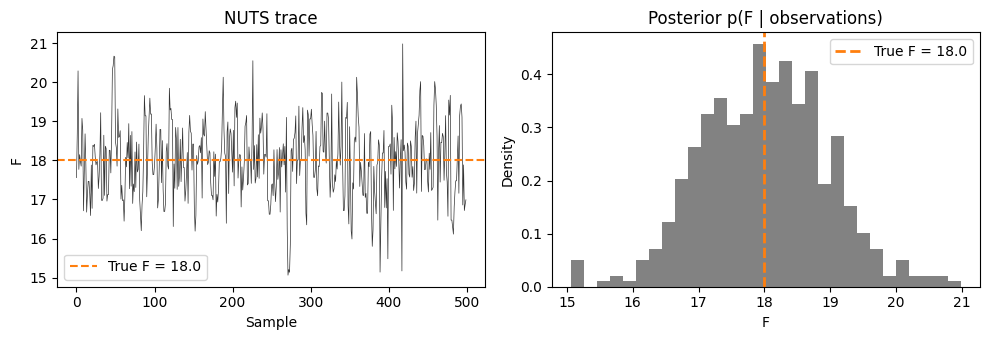

Posterior mean: F = 18.00 ± 0.96
True value:     F = 18.0


In [9]:
import arviz as az

nuts_samples = mcmc_nuts.get_samples()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Trace plot
axes[0].plot(np.array(nuts_samples["F"]), color=".2", lw=0.5)
axes[0].axhline(TRUE_F, color="C1", ls="--", label=f"True F = {TRUE_F}")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("F")
axes[0].set_title("NUTS trace")
axes[0].legend()

# Posterior density
axes[1].hist(np.array(nuts_samples["F"]), bins=30, density=True, color=".3", alpha=0.7)
axes[1].axvline(TRUE_F, color="C1", ls="--", lw=2, label=f"True F = {TRUE_F}")
axes[1].set_xlabel("F")
axes[1].set_ylabel("Density")
axes[1].set_title("Posterior p(F | observations)")
axes[1].legend()

plt.tight_layout()
plt.show()

F_mean = float(nuts_samples["F"].mean())
F_std = float(nuts_samples["F"].std())
print(f"Posterior mean: F = {F_mean:.2f} ± {F_std:.2f}")
print(f"True value:     F = {TRUE_F}")

## Step 6: The opaque simulator scenario

What if your simulator isn't written in JAX? What if it's a compiled Fortran binary, a commercial solver, or legacy code you can't modify?

Tesseract handles this too. The `lorenz_tesseract_finitediff` variant implements the same Lorenz 96 physics in **pure NumPy** (no JAX at all) and uses **finite-difference gradients**. From the outside, it exposes the same API — same `apply`, same `vector_jacobian_product` — so the NumPyro model doesn't change at all.

Let's build and run it.

In [10]:
%%bash
# Render build status statically instead of an animated spinner,
# which streams as noise in captured notebook output.
export TERM=dumb
tesseract build lorenz_tesseract_finitediff/

 [i] Building image ...


 [i] Built image sha256:9573d754877e, ['lorenz-finitediff:0.1.0', 'lorenz-finitediff:latest']


["lorenz-finitediff:0.1.0", "lorenz-finitediff:latest"]


In [11]:
lorenz_fd = Tesseract.from_image("lorenz-finitediff")
lorenz_fd.serve()

In [12]:
def bayesian_lorenz_model_fd(observations, x0, obs_gap, n_obs, std_obs):
    """Same model, but using the finite-difference Tesseract."""
    F = numpyro.sample("F", dist.Normal(15.0, 5.0))

    result = apply_tesseract(
        lorenz_fd,
        {
            "state": x0,
            "F": F,
            "dt": 0.005,
            "n_steps": obs_gap * n_obs,
        },
    )
    trajectory = result["result"]
    obs_indices = jnp.arange(obs_gap - 1, obs_gap * n_obs, obs_gap)
    predicted_obs = trajectory[obs_indices]

    numpyro.sample("obs", dist.Normal(predicted_obs, std_obs), obs=observations)


instrument(lorenz_fd)

# Run NUTS with finite-diff gradients
nuts_fd_kernel = NUTS(bayesian_lorenz_model_fd)
mcmc_nuts_fd = MCMC(
    nuts_fd_kernel,
    num_warmup=200,
    num_samples=500,
    num_chains=1,
    progress_bar=False,
)

reset_counts(lorenz_fd)
start = time.time()
mcmc_nuts_fd.run(
    jax.random.PRNGKey(0),
    observations=observations,
    x0=x0_jax,
    obs_gap=OBS_GAP,
    n_obs=N_OBS,
    std_obs=STD_OBS,
)
nuts_fd_time = time.time() - start

# The model differentiates only w.r.t. the scalar F, so each finite-difference
# VJP costs 2 forward evaluations inside the container (central differences:
# f(F + eps) and f(F - eps)). Differentiating a higher-dimensional input would
# scale this by 2 * (number of differentiated elements) — which is exactly why
# analytical gradients pull ahead for larger models.
FD_EVALS_PER_VJP = 2  # central differences w.r.t. the single parameter F
nuts_fd_counts = dict(lorenz_fd._eval_counts)
nuts_fd_fwd_evals = nuts_fd_counts["apply"] + FD_EVALS_PER_VJP * nuts_fd_counts["vjp"]

mcmc_nuts_fd.print_summary()
print(f"\nNUTS (finite-diff) wall time: {nuts_fd_time:.1f}s")
print(
    f"Forward-model calls: {nuts_fd_counts['apply']} apply + "
    f"{nuts_fd_counts['vjp']} VJP x {FD_EVALS_PER_VJP} "
    f"= {nuts_fd_fwd_evals} forward evaluations"
)
print(f"True F = {TRUE_F}")


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         F     18.06      1.00     18.02     16.48     19.55    178.70      1.00

Number of divergences: 0

NUTS (finite-diff) wall time: 64.8s
Forward-model calls: 2177 apply + 2176 VJP x 2 = 6529 forward evaluations
True F = 18.0


## Step 7: Gradient-free baseline

For comparison, let's run a gradient-free sampler. This mirrors the workflow without Tesseract's gradient endpoints — treating the simulator as a black-box function with no derivative information.

We use NumPyro's Stochastic Approximation (SA) sampler, which doesn't require gradients. To keep the comparison fair on compute, we give SA roughly the same number of forward-model evaluations that NUTS used — each SA iteration is a single forward call. Even with a matched budget, the gradient-free chain struggles to converge.

In [13]:
from numpyro.infer import SA

# SA is gradient-free: it never calls the VJP endpoint, only the forward model.
# To make the comparison fair on compute, we give SA roughly the same number of
# forward evaluations that NUTS used (each SA iteration is one forward call).
sa_total_iters = nuts_fwd_evals
sa_warmup = sa_total_iters // 2
sa_samples_n = sa_total_iters - sa_warmup

sa_kernel = SA(bayesian_lorenz_model)
mcmc_sa = MCMC(
    sa_kernel,
    num_warmup=sa_warmup,
    num_samples=sa_samples_n,
    num_chains=1,
    progress_bar=False,
)

reset_counts(lorenz)
start = time.time()
mcmc_sa.run(
    jax.random.PRNGKey(0),
    observations=observations,
    x0=x0_jax,
    obs_gap=OBS_GAP,
    n_obs=N_OBS,
    std_obs=STD_OBS,
)
sa_time = time.time() - start

sa_counts = dict(lorenz._eval_counts)
sa_fwd_evals = sa_counts["apply"] + sa_counts["vjp"]  # vjp is 0 for SA

mcmc_sa.print_summary()
print(f"\nSA (gradient-free) wall time: {sa_time:.1f}s")
print(
    f"Forward-model calls: {sa_fwd_evals} forward evaluations (matched to NUTS budget)"
)
print(f"True F = {TRUE_F}")


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         F     17.91      1.16     18.22     16.10     19.69     35.09      1.02

Number of divergences: 0

SA (gradient-free) wall time: 36.4s
Forward-model calls: 4073 forward evaluations (matched to NUTS budget)
True F = 18.0


## Step 8: Comparison

Let's compare all three approaches side by side: posterior quality, mixing, and efficiency. Alongside wall time we report the number of forward-model evaluations each method needed. Wall time is machine- and model-dependent, but the forward-evaluation count is the metric that generalizes: it is what grows when the simulator is expensive or the parameter space is high-dimensional.

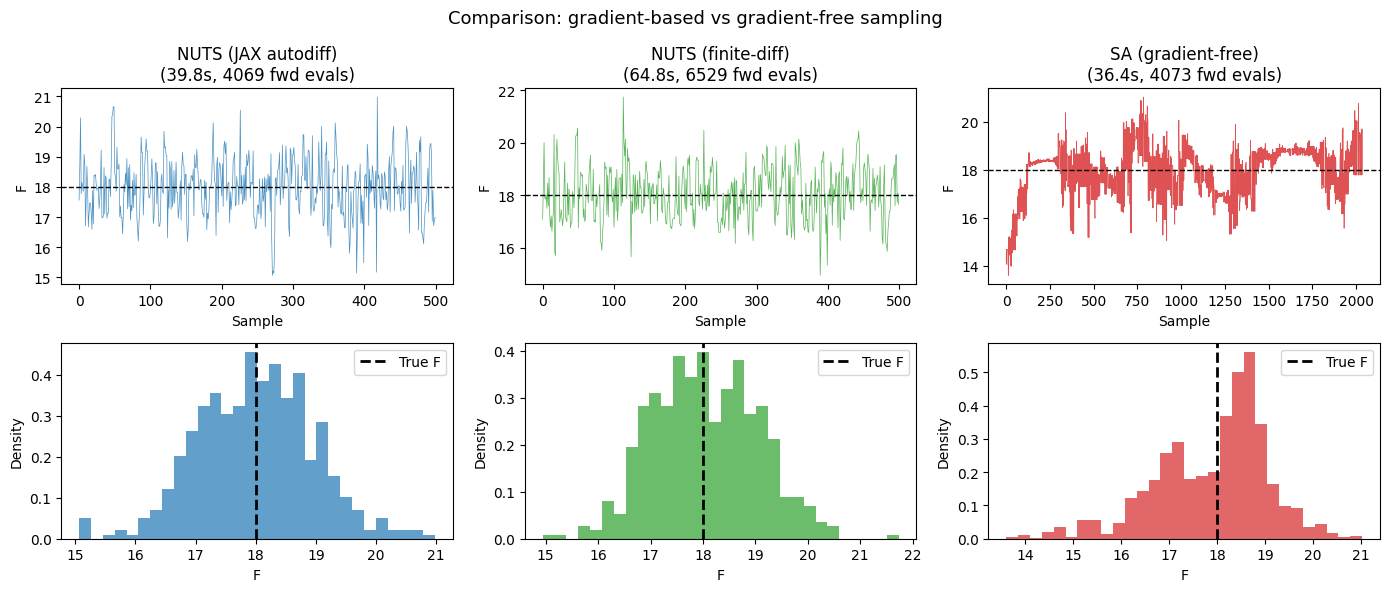

In [14]:
nuts_fd_samples = mcmc_nuts_fd.get_samples()
sa_samples = mcmc_sa.get_samples()

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

configs = [
    ("NUTS (JAX autodiff)", nuts_samples, nuts_time, nuts_fwd_evals, "C0"),
    ("NUTS (finite-diff)", nuts_fd_samples, nuts_fd_time, nuts_fd_fwd_evals, "C2"),
    ("SA (gradient-free)", sa_samples, sa_time, sa_fwd_evals, "C3"),
]

for i, (label, samples, wall_time, fwd_evals, color) in enumerate(configs):
    F_vals = np.array(samples["F"])

    # Trace plot
    axes[0, i].plot(F_vals, color=color, lw=0.5, alpha=0.8)
    axes[0, i].axhline(TRUE_F, color="k", ls="--", lw=1)
    axes[0, i].set_title(f"{label}\n({wall_time:.1f}s, {fwd_evals} fwd evals)")
    axes[0, i].set_ylabel("F")
    axes[0, i].set_xlabel("Sample")

    # Posterior histogram
    axes[1, i].hist(F_vals, bins=30, density=True, color=color, alpha=0.7)
    axes[1, i].axvline(TRUE_F, color="k", ls="--", lw=2, label="True F")
    axes[1, i].set_xlabel("F")
    axes[1, i].set_ylabel("Density")
    axes[1, i].legend()

plt.suptitle("Comparison: gradient-based vs gradient-free sampling", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Quantitative comparison
def compute_ess(samples):
    """Compute effective sample size using arviz."""
    return float(az.ess(samples))


results = []
for label, samples, wall_time, fwd_evals, _ in configs:
    F_vals = np.array(samples["F"])
    ess = compute_ess(F_vals)
    results.append(
        {
            "Method": label,
            "Posterior mean": f"{F_vals.mean():.2f}",
            "Posterior std": f"{F_vals.std():.2f}",
            "ESS": f"{ess:.0f}",
            "Wall time (s)": f"{wall_time:.1f}",
            "Fwd evals": f"{fwd_evals}",
            "ESS/sec": f"{ess / wall_time:.1f}",
            "ESS/1k evals": f"{1000 * ess / fwd_evals:.1f}",
        }
    )

# Print as a table
header = results[0].keys()
col_widths = {k: max(len(k), max(len(r[k]) for r in results)) + 2 for k in header}
header_str = "|".join(k.center(col_widths[k]) for k in header)
sep_str = "|".join("-" * col_widths[k] for k in header)
print(header_str)
print(sep_str)
for r in results:
    print("|".join(r[k].center(col_widths[k]) for k in header))

print(f"\nTrue F = {TRUE_F}")

        Method       | Posterior mean | Posterior std | ESS | Wall time (s) | Fwd evals | ESS/sec | ESS/1k evals 
---------------------|----------------|---------------|-----|---------------|-----------|---------|--------------
 NUTS (JAX autodiff) |     18.00      |      0.96     | 224 |      39.8     |    4069   |   5.6   |     55.1     
  NUTS (finite-diff) |     18.06      |      1.00     | 190 |      64.8     |    6529   |   2.9   |     29.1     
  SA (gradient-free) |     17.91      |      1.16     |  32 |      36.4     |    4073   |   0.9   |     7.9      

True F = 18.0


## Cleanup

In [16]:
lorenz.teardown()
lorenz_fd.teardown()

## Takeaways

1. **Tesseract + tesseract-jax makes simulators first-class citizens in NumPyro.** No custom callbacks, no manual VJP wiring — just `apply_tesseract` inside your model.

2. **Gradients dramatically improve sampling efficiency.** NUTS with gradients (whether analytical or finite-difference) recovers the true parameter and achieves high ESS, while the gradient-free sampler struggles to converge even when given a matched forward-evaluation budget.

3. **Count forward evaluations, not just wall time.** Here the model is cheap and we infer a single scalar, so finite-difference NUTS is only modestly more expensive than analytical NUTS — finite differences cost 2 forward evaluations per gradient (central differences w.r.t. one parameter). Differentiating a higher-dimensional input scales that by `2 × (number of parameters)`, while analytical autodiff stays at roughly one forward evaluation per gradient. For costly or high-dimensional models, that gap is what makes analytical gradients decisive.

4. **Opaque simulators work too.** Even without JAX autodiff, finite-difference gradients via Tesseract's experimental API give NUTS enough information to sample efficiently.

5. **One Tesseract, many contexts.** The same Lorenz 96 Tesseract we used here is the one from the [4D-Var data assimilation demo](data-assimilation.ipynb) — we only marked its forcing parameter `F` as differentiable. It also works in optimization pipelines and as a deployed service. Wrap once, use everywhere.

## What's next

- **Try a different prior or observation setup.** Adjust `OBS_GAP`, `N_OBS`, or the prior on $F$ to see how data quantity and prior strength shape the posterior.
- **Infer more parameters.** Extend the NumPyro model to recover the initial condition $X_0$ alongside the forcing $F$.
- **Swap the sampler.** Try other gradient-based kernels (e.g. HMC) or run multiple chains to assess convergence.
- **Explore other demos.** The same Lorenz 96 Tesseract also powers the [4D-Var data assimilation demo](data-assimilation.ipynb) — another way to compose Tesseracts with JAX.

Questions? Feedback? Please reach out through the [Tesseract Community Forum](https://si-tesseract.discourse.group/).